## Cell 1 — Imports & Environment Setup

In [1]:

import sys
import os
from pathlib import Path

# Resolve project root (one level up from notebooks/)
PROJECT_ROOT = Path("../").resolve()

# Add project root to Python path if not present
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"✅ Project root added to sys.path: {PROJECT_ROOT}")
print(f"📁 Project root  : {PROJECT_ROOT}")
print(f"📁 Working dir   : {Path.cwd()}")
print("🩺 MediQwen Semantic Scope Classifier")
print("==================================================")

from src.models.embeddings import initialize_embeddings, normalize_vectors

# Initialize using your codebase's existing loader
hf_embeddings = initialize_embeddings()
print("✅ Project embeddings loaded successfully!")



✅ Project root added to sys.path: C:\santosh\MediQwen
📁 Project root  : C:\santosh\MediQwen
📁 Working dir   : c:\santosh\MediQwen\notebooks
🩺 MediQwen Semantic Scope Classifier


c:\santosh\MediQwen\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔍 Initializing embedding model: BAAI/bge-large-en-v1.5
🔧 Using device: auto


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2565.20it/s]


✅ Project embeddings loaded successfully!


## Cell 2 — Define Prototype Datasets

In [ ]:
SCOPE_PROTOTYPES = {
    "MEDICAL": [
        "What are the treatment options for this condition?",
        "What could be causing this symptom?",
        "Why does my skin itch?",
        "Should I see a doctor?",
        "What are the warning signs?",
        "How can I manage this condition?",
        "What medications are commonly used?",
        "Is this symptom serious?",
        "What can I do to relieve these symptoms?",
        "What are the possible causes?",
        "How is this diagnosed?",
        "What are the complications of this illness?",
        "When should I seek medical help?"
    ],

    "NUTRITION": [
        "What is a healthy diet?",
        "What foods are good for heart health?",
        "What should I eat to get more protein?",
        "What foods should I avoid?",
        "Can you suggest a healthy meal?",
        "How can I improve my diet?",
        "What nutrients do I need?",
        "What are healthy foods for breakfast?",
        "How much protein should I eat?",
        "What is a balanced diet?"
    ],

    "CASUAL": [
        "How are you?",
        "Tell me something interesting.",
        "Good morning.",
        "Let's chat.",
        "What can you do?",
        "Tell me about yourself.",
        "How is your day?",
        "What's something fun to talk about?",
        "Can we have a conversation?",
        "Hello",
        "Thank you very much",
        "Okay sounds good"
    ],

    "OUT_OF_SCOPE": [
        "Write Python code for a game.",
        "Explain quantum computing.",
        "Help me configure a Linux server.",
        "Write a marketing strategy.",
        "How do I build a website?",
        "Tell me a joke.",
        "Help me debug this JavaScript code.",
        "Explain how a car engine works.",
        "Write a Python web scraper.",
        "Help me with my programming assignment.",
        "Explain computer networking.",
        "What is the stock market trend today?",
        "Who won the football game?"
    ]
}

## Cell 3 — Generate & Cache Prototype Embeddings

In [3]:
import numpy as np

# BAAI/bge-large-en-v1.5 performs better when queries have instructions or normalized embeddings
prototype_embeddings = {}

for scope, examples in SCOPE_PROTOTYPES.items():
    # Embed using LangChain HuggingFace interface
    raw_vecs = hf_embeddings.embed_documents(examples)
    norm_vecs = normalize_vectors(np.array(raw_vecs))
    prototype_embeddings[scope] = norm_vecs
    print(f"Scope: {scope:<12} | Matrix Shape: {norm_vecs.shape}")

Scope: MEDICAL      | Matrix Shape: (13, 1024)
Scope: NUTRITION    | Matrix Shape: (10, 1024)
Scope: CASUAL       | Matrix Shape: (12, 1024)
Scope: OUT_OF_SCOPE | Matrix Shape: (12, 1024)


## Cell 4 — Define Cosine Classifier Function

In [4]:
import time

def classify_scope_semantic(query: str, top_k: int = 3):
    start_time = time.perf_counter()
    
    # Embed query using embed_query + normalize_vectors
    raw_query = hf_embeddings.embed_query(query)
    query_vec = normalize_vectors(np.array([raw_query]))[0]
    
    scores = {}
    topk_avg_scores = {}

    for scope, emb_matrix in prototype_embeddings.items():
        # Dot product with all prototypes in category
        sims = emb_matrix @ query_vec
        
        # Max similarity
        scores[scope] = float(np.max(sims))
        
        # Top-K average similarity
        top_k_sims = np.sort(sims)[-top_k:]
        topk_avg_scores[scope] = float(np.mean(top_k_sims))

    # Sort by max score
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    best_scope, best_score = ranked[0]
    second_scope, second_score = ranked[1]
    
    margin = best_score - second_score
    elapsed_ms = (time.perf_counter() - start_time) * 1000

    return {
        "query": query,
        "best_scope": best_scope,
        "best_score": round(best_score, 4),
        "second_scope": second_scope,
        "second_score": round(second_score, 4),
        "margin": round(margin, 4),
        "scores": {k: round(v, 4) for k, v in scores.items()},
        "topk_avg_scores": {k: round(v, 4) for k, v in topk_avg_scores.items()},
        "latency_ms": round(elapsed_ms, 2)
    }

## Cell 5 — Test Failure Cases & Adversarial Queries

In [6]:
import pandas as pd

test_suite = [
    # 1. Previously Failed Follow-Up Queries (Should be MEDICAL)
    "what are the possible treatments for this?",
    "what are the treatment options?",
    "how do I manage this?",
    "is this dangerous?",
    "what about the warning signs?",
    "what causes hives?",
    
    # 2. Nutrition Intent
    "what should I eat for a healthy heart?",
    "what foods contain high vitamin D?",
    
    # 3. Casual Intent
    "hello how are you",
    "thank you for your advice",
    
    # 4. Clear Out-of-Scope (Should be OUT_OF_SCOPE)
    "Write Python code for a game.",
    "Explain quantum computing.",
    "Help me configure a Linux server.",
    
    # 5. Context-Switch / Adversarial Queries (Crucial Test!)
    "Write Python code to analyze hives.",
    "Tell me a joke about psoriasis.",
    "Build a web scraper for clinical guidelines."
]

results = []
for q in test_suite:
    res = classify_scope_semantic(q)
    results.append({
        "Query": res["query"],
        "Predicted Scope": res["best_scope"],
        "Score": res["best_score"],
        "Margin": res["margin"],
        "Medical Sim": res["scores"]["MEDICAL"],
        "OOS Sim": res["scores"]["OUT_OF_SCOPE"],
        "Latency (ms)": res["latency_ms"]
    })

df_results = pd.DataFrame(results)
display(df_results)

,Query,Predicted Scope,Score,Margin,Medical Sim,OOS Sim,Latency (ms)
0,what are the possible treatments for this?,MEDICAL,0.9058,0.2590,0.9058,0.4809,66.57
1,what are the treatment options?,MEDICAL,0.9204,0.2353,0.9204,0.4723,63.77
2,how do I manage this?,MEDICAL,0.8873,0.2083,0.8873,0.5669,50.71
3,is this dangerous?,MEDICAL,0.6989,0.1207,0.6989,0.5216,49.13
4,what about the warning signs?,MEDICAL,0.9006,0.3075,0.9006,0.4565,42.15
5,what causes hives?,MEDICAL,0.6469,0.1806,0.6469,0.3691,44.13
6,what should I eat for a healthy heart?,NUTRITION,0.9112,0.4017,0.5095,0.4159,51.69
7,what foods contain high vitamin D?,NUTRITION,0.6657,0.2151,0.4507,0.3540,47.56
8,hello how are you,CASUAL,0.9169,0.3658,0.5511,0.5153,40.96
9,thank you for your advice,CASUAL,0.7764,0.1485,0.6279,0.5160,51.81


## Cell 6 — Expanded Benchmark Dataset (100 Labeled Queries)

Following the calibration plan: 30 MEDICAL / 20 NUTRITION / 20 CASUAL / 30 OUT_OF_SCOPE, deliberately including short follow-up queries, context-dependent phrasing, and context-switch / adversarial cases (medical vocabulary wrapped in a non-medical intent).

In [ ]:
from collections import Counter

BENCHMARK = [
    # ---------------- MEDICAL — STANDALONE ----------------
    ("Why does my skin itch?", "MEDICAL", "STANDALONE"),
    ("What medications are commonly used?", "MEDICAL", "STANDALONE"),
    ("Should I see a doctor?", "MEDICAL", "STANDALONE"),
    ("When should I seek medical help?", "MEDICAL", "STANDALONE"),
    ("what causes hives?", "MEDICAL", "STANDALONE"),
    ("What should I eat after a heart attack?", "MEDICAL", "STANDALONE"),          # medical/nutrition boundary
    ("What are the symptoms of vitamin B12 deficiency?", "MEDICAL", "STANDALONE"),  # medical/nutrition boundary
    ("What are the main causes of shortness of breath?", "MEDICAL", "STANDALONE"),
    ("Is high blood pressure reversible?", "MEDICAL", "STANDALONE"),
    ("How is type 2 diabetes managed?", "MEDICAL", "STANDALONE"),
    ("What are the early signs of a stroke?", "MEDICAL", "STANDALONE"),
    ("Can stress cause chest tightness?", "MEDICAL", "STANDALONE"),
    ("What side effects does amoxicillin have?", "MEDICAL", "STANDALONE"),
    ("How long is an ear infection contagious?", "MEDICAL", "STANDALONE"),
    ("What is the difference between cold and flu?", "MEDICAL", "STANDALONE"),
    ("When is a fever considered dangerously high?", "MEDICAL", "STANDALONE"),
    ("What triggers asthma attacks?", "MEDICAL", "STANDALONE"),

    # ---------------- MEDICAL — CONTEXTUAL ----------------
    # Anaphoric ("this"/"it"/"these"), but medical-specific vocabulary
    ("What are the possible treatments for this condition?", "MEDICAL", "CONTEXTUAL"),
    ("What could be causing this symptom?", "MEDICAL", "CONTEXTUAL"),
    ("What are the warning signs?", "MEDICAL", "CONTEXTUAL"),
    ("How can I manage this condition?", "MEDICAL", "CONTEXTUAL"),
    ("Is this symptom serious?", "MEDICAL", "CONTEXTUAL"),
    ("What can I do to relieve these symptoms?", "MEDICAL", "CONTEXTUAL"),
    ("What are the possible causes?", "MEDICAL", "CONTEXTUAL"),
    ("How is this diagnosed?", "MEDICAL", "CONTEXTUAL"),
    ("What are the complications of this illness?", "MEDICAL", "CONTEXTUAL"),
    ("what should I do about this?", "MEDICAL", "CONTEXTUAL"),
    ("could this be serious?", "MEDICAL", "CONTEXTUAL"),
    ("what causes it?", "MEDICAL", "CONTEXTUAL"),
    ("what are the early symptoms of this?", "MEDICAL", "CONTEXTUAL"),
    ("what happens if I leave it untreated?", "MEDICAL", "CONTEXTUAL"),
    ("what about treatment?", "MEDICAL", "CONTEXTUAL"),
    ("how long does recovery usually take?", "MEDICAL", "CONTEXTUAL"),
    ("is this contagious?", "MEDICAL", "CONTEXTUAL"),
    ("What can I do about this?", "MEDICAL", "CONTEXTUAL"),
    ("Is this okay?", "MEDICAL", "CONTEXTUAL"),
    ("What about this?", "MEDICAL", "CONTEXTUAL"),
    ("Can you help me with this?", "MEDICAL", "CONTEXTUAL"),
    ("What are the options?", "MEDICAL", "CONTEXTUAL"),
    ("Will this rash spread to other areas?", "MEDICAL", "CONTEXTUAL"),
    ("Is there an over-the-counter cure for this?", "MEDICAL", "CONTEXTUAL"),
    ("How can I reduce swelling from this injury?", "MEDICAL", "CONTEXTUAL"),
    ("What specialist treats this kind of condition?", "MEDICAL", "CONTEXTUAL"),
    ("Should I keep this wound covered or open?", "MEDICAL", "CONTEXTUAL"),
    ("Are these side effects permanent?", "MEDICAL", "CONTEXTUAL"),
    ("Does this mean I need surgery?", "MEDICAL", "CONTEXTUAL"),
    ("Can this illness cause long-term pain?", "MEDICAL", "CONTEXTUAL"),
    ("How do I know if this infection is healing?", "MEDICAL", "CONTEXTUAL"),
    ("Could this be an allergic reaction?", "MEDICAL", "CONTEXTUAL"),

    # ---------------- MEDICAL — AMBIGUOUS ----------------
    # Domain-neutral queries; used to test Stage 2 Context Resolver fallback
    ("treatments?", "MEDICAL", "AMBIGUOUS"),
    ("how can I make it better?", "MEDICAL", "AMBIGUOUS"),
    ("is this something I should worry about?", "MEDICAL", "AMBIGUOUS"),
    ("how do I manage this?", "MEDICAL", "AMBIGUOUS"),
    ("what should I do now?", "MEDICAL", "AMBIGUOUS"),
    ("can this get worse?", "MEDICAL", "AMBIGUOUS"),
    ("is this dangerous?", "MEDICAL", "AMBIGUOUS"),
    ("what are my options?", "MEDICAL", "AMBIGUOUS"),
    ("What should I do?", "MEDICAL", "AMBIGUOUS"),
    ("is it getting worse?", "MEDICAL", "AMBIGUOUS"),
    ("what happens next?", "MEDICAL", "AMBIGUOUS"),
    ("how long will this take?", "MEDICAL", "AMBIGUOUS"),
    ("should I stop?", "MEDICAL", "AMBIGUOUS"),
    ("can it go away on its own?", "MEDICAL", "AMBIGUOUS"),
    ("is there anything else I can try?", "MEDICAL", "AMBIGUOUS"),
    ("how do I know if it worked?", "MEDICAL", "AMBIGUOUS"),
    ("what is the main cause?", "MEDICAL", "AMBIGUOUS"),
    ("is this normal?", "MEDICAL", "AMBIGUOUS"),
    ("what do you recommend for it?", "MEDICAL", "AMBIGUOUS"),

    # ---------------- NUTRITION — STANDALONE ----------------
    ("What is a healthy diet?", "NUTRITION", "STANDALONE"),
    ("What foods are good for heart health?", "NUTRITION", "STANDALONE"),
    ("What should I eat to get more protein?", "NUTRITION", "STANDALONE"),
    ("What foods should I avoid?", "NUTRITION", "STANDALONE"),
    ("Can you suggest a healthy meal?", "NUTRITION", "STANDALONE"),
    ("How can I improve my diet?", "NUTRITION", "STANDALONE"),
    ("What nutrients do I need?", "NUTRITION", "STANDALONE"),
    ("What are healthy foods for breakfast?", "NUTRITION", "STANDALONE"),
    ("How much protein should I eat?", "NUTRITION", "STANDALONE"),
    ("What is a balanced diet?", "NUTRITION", "STANDALONE"),
    ("what should I eat for a healthy heart?", "NUTRITION", "STANDALONE"),
    ("what foods contain high vitamin D?", "NUTRITION", "STANDALONE"),
    ("Is intermittent fasting healthy?", "NUTRITION", "STANDALONE"),
    ("What are good sources of fiber?", "NUTRITION", "STANDALONE"),
    ("How many calories should I eat per day?", "NUTRITION", "STANDALONE"),
    ("What snacks are healthy for weight loss?", "NUTRITION", "STANDALONE"),
    ("Are carbs bad for me?", "NUTRITION", "STANDALONE"),
    ("What vitamins should I take daily?", "NUTRITION", "STANDALONE"),
    ("What foods help lower cholesterol?", "NUTRITION", "STANDALONE"),
    ("Should I cut down on sugar?", "NUTRITION", "STANDALONE"),
    ("What diet is recommended for diabetes?", "NUTRITION", "STANDALONE"),        # medical/nutrition boundary
    ("Can food help with high blood pressure?", "NUTRITION", "STANDALONE"),      # medical/nutrition boundary
    ("What foods contain vitamin B12?", "NUTRITION", "STANDALONE"),              # medical/nutrition boundary
    ("What should I eat if I have anemia?", "NUTRITION", "STANDALONE"),          # medical/nutrition boundary
    ("Are plant-based proteins as effective as whey?", "NUTRITION", "STANDALONE"),
    ("What foods increase gut microbiome diversity?", "NUTRITION", "STANDALONE"),
    ("How much sodium is allowed in a low-salt diet?", "NUTRITION", "STANDALONE"),
    ("What are the health benefits of Mediterranean diet?", "NUTRITION", "STANDALONE"),
    ("Should I drink electrolyte water after workouts?", "NUTRITION", "STANDALONE"),
    ("What foods contain healthy fats like omega-3?", "NUTRITION", "STANDALONE"),
    ("Is intake of artificial sweeteners harmful?", "NUTRITION", "STANDALONE"),
    ("What are good iron-rich foods for vegetarians?", "NUTRITION", "STANDALONE"),
    ("How does meal timing affect metabolism?", "NUTRITION", "STANDALONE"),
    ("What foods help prevent muscle loss during fasting?", "NUTRITION", "STANDALONE"),

    # ---------------- CASUAL — STANDALONE ----------------
    ("How are you?", "CASUAL", "STANDALONE"),
    ("Tell me something interesting.", "CASUAL", "STANDALONE"),
    ("Good morning.", "CASUAL", "STANDALONE"),
    ("Let's chat.", "CASUAL", "STANDALONE"),
    ("What can you do?", "CASUAL", "STANDALONE"),
    ("Tell me a joke.", "CASUAL", "STANDALONE"),
    ("How is your day?", "CASUAL", "STANDALONE"),
    ("What's something fun to talk about?", "CASUAL", "STANDALONE"),
    ("Can we have a conversation?", "CASUAL", "STANDALONE"),
    ("Hello", "CASUAL", "STANDALONE"),
    ("Thank you very much", "CASUAL", "STANDALONE"),
    ("Okay sounds good", "CASUAL", "STANDALONE"),
    ("hello how are you", "CASUAL", "STANDALONE"),
    ("thank you for your advice", "CASUAL", "STANDALONE"),
    ("What's your favorite thing to talk about?", "CASUAL", "STANDALONE"),
    ("Tell me a joke about psoriasis.", "CASUAL", "STANDALONE"),
    ("See you later", "CASUAL", "STANDALONE"),
    ("That's helpful, thanks", "CASUAL", "STANDALONE"),
    ("What's up?", "CASUAL", "STANDALONE"),
    ("Good night", "CASUAL", "STANDALONE"),
    ("Make a joke about hospitals.", "CASUAL", "STANDALONE"),
    ("Explain psoriasis as a character in a novel.", "CASUAL", "STANDALONE"),
    ("Nice to meet you!", "CASUAL", "STANDALONE"),
    ("Who created you?", "CASUAL", "STANDALONE"),
    ("Tell me a fun fact about space.", "CASUAL", "STANDALONE"),
    ("I'm feeling bored today.", "CASUAL", "STANDALONE"),
    ("Can you sing a song?", "CASUAL", "STANDALONE"),
    ("Are you an AI or a real human?", "CASUAL", "STANDALONE"),
    ("What is your name?", "CASUAL", "STANDALONE"),
    ("Have a great afternoon!", "CASUAL", "STANDALONE"),
    ("Write a poem about a hospital nurse.", "CASUAL", "STANDALONE"),
    ("Tell me a funny story about a doctor.", "CASUAL", "STANDALONE"),

    # ---------------- OUT_OF_SCOPE — STANDALONE ----------------
    ("Write Python code for a game.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Explain quantum computing.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Help me configure a Linux server.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a marketing strategy.", "OUT_OF_SCOPE", "STANDALONE"),
    ("How do I build a website?", "OUT_OF_SCOPE", "STANDALONE"),
    ("Help me debug this JavaScript code.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Explain how a car engine works.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a Python web scraper.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Help me with my programming assignment.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Explain computer networking.", "OUT_OF_SCOPE", "STANDALONE"),
    ("What is the stock market trend today?", "OUT_OF_SCOPE", "STANDALONE"),
    ("Who won the football game?", "OUT_OF_SCOPE", "STANDALONE"),
    ("write Python code", "OUT_OF_SCOPE", "STANDALONE"),
    ("debug this JavaScript", "OUT_OF_SCOPE", "STANDALONE"),
    ("explain quantum mechanics", "OUT_OF_SCOPE", "STANDALONE"),
    ("help me configure Docker", "OUT_OF_SCOPE", "STANDALONE"),
    ("write a web scraper", "OUT_OF_SCOPE", "STANDALONE"),
    ("create a game", "OUT_OF_SCOPE", "STANDALONE"),
    ("explain stock trading", "OUT_OF_SCOPE", "STANDALONE"),
    ("help me design a website", "OUT_OF_SCOPE", "STANDALONE"),
    ("Recommend a good sci-fi movie.", "OUT_OF_SCOPE", "STANDALONE"),
    ("What's the weather like today?", "OUT_OF_SCOPE", "STANDALONE"),
    ("Help me plan a vacation itinerary.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Translate this sentence into French.", "OUT_OF_SCOPE", "STANDALONE"),

    # ---------------- OUT_OF_SCOPE — adversarial (medical topic, non-medical intent) ----------------
    ("Write Python code to analyze hives.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Build a web scraper for clinical guidelines.", "OUT_OF_SCOPE", "STANDALONE"),
    ("write Python code to analyze this", "OUT_OF_SCOPE", "STANDALONE"),
    ("write a scraper for this condition", "OUT_OF_SCOPE", "STANDALONE"),
    ("explain quantum computing using this medical example", "OUT_OF_SCOPE", "STANDALONE"),
    ("generate HTML for this diagnosis", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write Python code to calculate BMI.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Create a Python program for a medical chatbot.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Build a machine learning model to classify skin lesions.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write code to detect pneumonia from X-rays.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a story about a doctor treating a dragon.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a Python program about diabetes statistics.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Build a React dashboard for hospital patient records.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a SQL query to extract patient symptom data.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Explain the physics of MRI magnet resonance.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a bash script to backup clinical PDF documents.", "OUT_OF_SCOPE", "STANDALONE"),
    ("How do I fix a broken car air conditioner?", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a resume for a clinical software developer.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Build a machine learning pipeline using HuggingFace.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Write a regex pattern to match ICD-10 medical codes.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Explain the history of the French Revolution.", "OUT_OF_SCOPE", "STANDALONE"),
    ("Create a CMake file for a C++ medical imaging library.", "OUT_OF_SCOPE", "STANDALONE"),
]

print(f"Total: {len(BENCHMARK)}")
print("By label:    ", Counter(l for _, l, _ in BENCHMARK))
print("By test_type:", Counter(t for _, _, t in BENCHMARK))

Total: 180
By label:     Counter({'MEDICAL': 68, 'OUT_OF_SCOPE': 46, 'NUTRITION': 34, 'CASUAL': 32})
By test_type: Counter({'STANDALONE': 129, 'CONTEXTUAL': 32, 'AMBIGUOUS': 19})


## Cell 7 — Run Classifier Over the Benchmark

In [8]:
import pandas as pd
import numpy as np

results = []
for query, true_label, test_label in BENCHMARK:
    res = classify_scope_semantic(query)
    results.append({
        "Query": query,
        "True Label": true_label,
        "Test Label": test_label,
        "Predicted": res["best_scope"],
        "Correct": res["best_scope"] == true_label,
        "Score": res["best_score"],
        "Second Scope": res["second_scope"],
        "Margin": res["margin"],
        "MEDICAL Sim": res["scores"]["MEDICAL"],
        "NUTRITION Sim": res["scores"]["NUTRITION"],
        "CASUAL Sim": res["scores"]["CASUAL"],
        "OOS Sim": res["scores"]["OUT_OF_SCOPE"],
        "Latency (ms)": res["latency_ms"],
    })

df_bench = pd.DataFrame(results)
overall_acc = df_bench["Correct"].mean()
print(f"Overall accuracy on {len(df_bench)} queries: {overall_acc:.2%}")
df_bench.head(10)


Overall accuracy on 180 queries: 90.56%


,Query,True Label,Test Label,Predicted,Correct,Score,Second Scope,Margin,MEDICAL Sim,NUTRITION Sim,CASUAL Sim,OOS Sim,Latency (ms)
0,Why does my skin itch?,MEDICAL,STANDALONE,MEDICAL,True,1.0000,NUTRITION,0.5733,1.0000,0.4267,0.4161,0.3603,81.05
1,What medications are commonly used?,MEDICAL,STANDALONE,MEDICAL,True,1.0000,NUTRITION,0.5087,1.0000,0.4913,0.4654,0.4027,51.98
2,Should I see a doctor?,MEDICAL,STANDALONE,MEDICAL,True,1.0000,NUTRITION,0.4370,1.0000,0.5630,0.5563,0.4231,53.97
3,When should I seek medical help?,MEDICAL,STANDALONE,MEDICAL,True,1.0000,NUTRITION,0.4270,1.0000,0.5730,0.5490,0.4461,54.92
4,what causes hives?,MEDICAL,STANDALONE,MEDICAL,True,0.6469,NUTRITION,0.1806,0.6469,0.4663,0.4334,0.3691,43.66
5,What should I eat after a heart attack?,MEDICAL,STANDALONE,NUTRITION,False,0.7898,MEDICAL,0.2156,0.5742,0.7898,0.5144,0.4090,44.93
6,What are the symptoms of vitamin B12 deficiency?,MEDICAL,STANDALONE,MEDICAL,True,0.6227,NUTRITION,0.0503,0.6227,0.5724,0.4292,0.4230,45.52
7,What are the main causes of shortness of breath?,MEDICAL,STANDALONE,MEDICAL,True,0.6566,NUTRITION,0.2091,0.6566,0.4476,0.3766,0.3737,49.01
8,Is high blood pressure reversible?,MEDICAL,STANDALONE,MEDICAL,True,0.5054,NUTRITION,0.0204,0.5054,0.4850,0.4356,0.4100,43.41
9,How is type 2 diabetes managed?,MEDICAL,STANDALONE,MEDICAL,True,0.6070,NUTRITION,0.0692,0.6070,0.5378,0.5141,0.4306,44.62


In [9]:
df_bench.groupby("Test Label")["Correct"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
Test Label,,,
AMBIGUOUS,19,13,0.684211
CONTEXTUAL,32,28,0.875000
STANDALONE,129,122,0.945736


In [17]:
df_bench[df_bench["Test Label"] == "AMBIGUOUS"].sort_values("Margin")[
    ["Query", "True Label", "Predicted", "Score", "Margin", "Correct"]
]

,Query,True Label,Predicted,Score,Margin,Correct
63,is there anything else I can try?,MEDICAL,MEDICAL,0.7153,0.0046,True
64,how do I know if it worked?,MEDICAL,MEDICAL,0.6231,0.0285,True
67,what do you recommend for it?,MEDICAL,CASUAL,0.6695,0.0314,False
60,how long will this take?,MEDICAL,MEDICAL,0.6225,0.0376,True
50,how can I make it better?,MEDICAL,NUTRITION,0.6958,0.0381,False
57,What should I do?,MEDICAL,CASUAL,0.7683,0.0422,False
56,what are my options?,MEDICAL,CASUAL,0.7812,0.0428,False
53,what should I do now?,MEDICAL,CASUAL,0.7332,0.0673,False
59,what happens next?,MEDICAL,CASUAL,0.6924,0.0696,False
66,is this normal?,MEDICAL,MEDICAL,0.6920,0.0721,True


In [18]:
df_bench[
    (df_bench["Test Label"] == "AMBIGUOUS") &
    (~df_bench["Correct"])
].sort_values("Margin")[
    ["Query", "True Label", "Predicted", "Score", "Margin"]
]

,Query,True Label,Predicted,Score,Margin
67,what do you recommend for it?,MEDICAL,CASUAL,0.6695,0.0314
50,how can I make it better?,MEDICAL,NUTRITION,0.6958,0.0381
57,What should I do?,MEDICAL,CASUAL,0.7683,0.0422
56,what are my options?,MEDICAL,CASUAL,0.7812,0.0428
53,what should I do now?,MEDICAL,CASUAL,0.7332,0.0673
59,what happens next?,MEDICAL,CASUAL,0.6924,0.0696


In [19]:
df_ambiguous = df_bench[
    df_bench["Test Label"] == "AMBIGUOUS"
].sort_values("Margin")

df_ambiguous[
    ["Query", "True Label", "Predicted", "Score", "Margin", "Correct"]
]

,Query,True Label,Predicted,Score,Margin,Correct
63,is there anything else I can try?,MEDICAL,MEDICAL,0.7153,0.0046,True
64,how do I know if it worked?,MEDICAL,MEDICAL,0.6231,0.0285,True
67,what do you recommend for it?,MEDICAL,CASUAL,0.6695,0.0314,False
60,how long will this take?,MEDICAL,MEDICAL,0.6225,0.0376,True
50,how can I make it better?,MEDICAL,NUTRITION,0.6958,0.0381,False
57,What should I do?,MEDICAL,CASUAL,0.7683,0.0422,False
56,what are my options?,MEDICAL,CASUAL,0.7812,0.0428,False
53,what should I do now?,MEDICAL,CASUAL,0.7332,0.0673,False
59,what happens next?,MEDICAL,CASUAL,0.6924,0.0696,False
66,is this normal?,MEDICAL,MEDICAL,0.6920,0.0721,True


In [20]:
df_ambiguous.groupby("Correct")["Margin"].describe()

,count,mean,std,min,25%,50%,75%,max
Correct,,,,,,,,
False,6.0,0.048567,0.015946,0.0314,0.039125,0.0425,0.061175,0.0696
True,13.0,0.114315,0.077608,0.0046,0.072100,0.1014,0.138700,0.2652


Misclassified queries are the most useful signal for threshold/margin tuning — inspect them directly:

In [15]:
df_errors = df_bench[~df_bench["Correct"]].sort_values("Margin")
print(f"{len(df_errors)} misclassified out of {len(df_bench)}")
df_errors[["Query", "True Label", "Predicted", "Score", "Margin"]]


17 misclassified out of 180


,Query,True Label,Predicted,Score,Margin
168,Write a story about a doctor treating a dragon.,OUT_OF_SCOPE,CASUAL,0.5598,0.0030
123,Explain psoriasis as a character in a novel.,CASUAL,OUT_OF_SCOPE,0.5107,0.0044
37,Can you help me with this?,MEDICAL,CASUAL,0.7144,0.0072
157,Translate this sentence into French.,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
35,Is this okay?,MEDICAL,CASUAL,0.6714,0.0258
67,what do you recommend for it?,MEDICAL,CASUAL,0.6695,0.0314
163,generate HTML for this diagnosis,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370
50,how can I make it better?,MEDICAL,NUTRITION,0.6958,0.0381
57,What should I do?,MEDICAL,CASUAL,0.7683,0.0422
56,what are my options?,MEDICAL,CASUAL,0.7812,0.0428


## Cell 8 — Confusion Matrix

In [2]:
! pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.5 MB 11.3 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.5 MB 11.3 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 10.1 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   --------------------------------- ------ 2.1/2.5 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 6.7 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   -----------------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


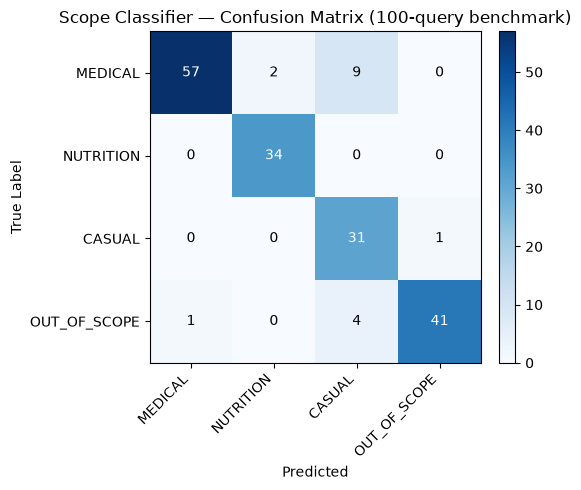

              precision    recall  f1-score   support

     MEDICAL       0.98      0.84      0.90        68
   NUTRITION       0.94      1.00      0.97        34
      CASUAL       0.70      0.97      0.82        32
OUT_OF_SCOPE       0.98      0.89      0.93        46

    accuracy                           0.91       180
   macro avg       0.90      0.92      0.91       180
weighted avg       0.92      0.91      0.91       180



In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

labels_order = ["MEDICAL", "NUTRITION", "CASUAL", "OUT_OF_SCOPE"]
cm = confusion_matrix(df_bench["True Label"], df_bench["Predicted"], labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_order)))
ax.set_yticks(range(len(labels_order)))
ax.set_xticklabels(labels_order, rotation=45, ha="right")
ax.set_yticklabels(labels_order)
ax.set_xlabel("Predicted")
ax.set_ylabel("True Label")
ax.set_title("Scope Classifier — Confusion Matrix (100-query benchmark)")

for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(classification_report(df_bench["True Label"], df_bench["Predicted"], labels=labels_order))


## Cell 9 — Score & Margin Distributions by Class

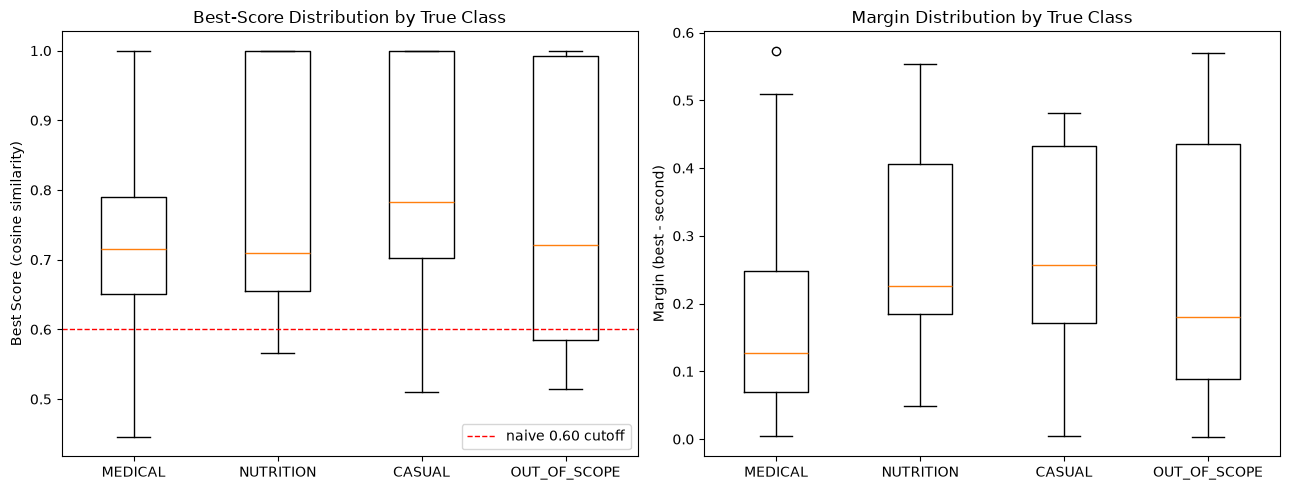

Score summary by class:
                 min       25%      50%      75%  max
True Label                                           
CASUAL        0.5107  0.701875  0.78325  1.00000  1.0
MEDICAL       0.4455  0.650800  0.71485  0.79060  1.0
NUTRITION     0.5661  0.655750  0.71005  1.00000  1.0
OUT_OF_SCOPE  0.5148  0.585025  0.72110  0.99185  1.0


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

data_by_class = [df_bench.loc[df_bench["True Label"] == lbl, "Score"] for lbl in labels_order]
axes[0].boxplot(data_by_class, tick_labels=labels_order)
axes[0].set_title("Best-Score Distribution by True Class")
axes[0].set_ylabel("Best Score (cosine similarity)")
axes[0].axhline(0.60, color="red", linestyle="--", linewidth=1, label="naive 0.60 cutoff")
axes[0].legend()

margin_by_class = [df_bench.loc[df_bench["True Label"] == lbl, "Margin"] for lbl in labels_order]
axes[1].boxplot(margin_by_class, tick_labels=labels_order)
axes[1].set_title("Margin Distribution by True Class")
axes[1].set_ylabel("Margin (best - second)")

plt.tight_layout()
plt.show()

print("Score summary by class:")
print(df_bench.groupby("True Label")["Score"].describe()[["min", "25%", "50%", "75%", "max"]])


## Cell 10 — Threshold × Margin Grid Search

For each (confidence, margin) pair, a query is only auto-resolved when it is `CONFIDENT`; `UNCERTAIN` queries are meant to fall through to the context resolver rather than being scored right/wrong here. So the metrics we actually care about are: **accuracy among CONFIDENT predictions** (never trust a confident answer that's wrong) and **coverage** (don't push so many queries to UNCERTAIN that the context resolver is doing all the work).

In [10]:
confidence_grid = [0.50, 0.55, 0.60, 0.65, 0.70]
margin_grid = [0.00, 0.03, 0.05, 0.10]

grid_rows = []
for conf_t in confidence_grid:
    for margin_t in margin_grid:
        is_confident = (df_bench["Score"] >= conf_t) & (df_bench["Margin"] >= margin_t)
        n_confident = is_confident.sum()
        coverage = n_confident / len(df_bench)

        if n_confident > 0:
            confident_acc = df_bench.loc[is_confident, "Correct"].mean()
            # the failure mode we most want to avoid: a CONFIDENT wrong answer
            n_confident_wrong = (is_confident & ~df_bench["Correct"]).sum()
        else:
            confident_acc = float("nan")
            n_confident_wrong = 0

        grid_rows.append({
            "Confidence Threshold": conf_t,
            "Margin Threshold": margin_t,
            "Coverage": round(coverage, 3),
            "Confident Accuracy": round(confident_acc, 3) if n_confident else None,
            "Confident-but-Wrong (count)": n_confident_wrong,
        })

df_grid = pd.DataFrame(grid_rows)

# Rank candidates: zero confident-wrong first, then maximize coverage
df_grid_sorted = df_grid.sort_values(
    by=["Confident-but-Wrong (count)", "Coverage"],
    ascending=[True, False]
)
df_grid_sorted.head(15)


,Confidence Threshold,Margin Threshold,Coverage,Confident Accuracy,Confident-but-Wrong (count)
3,0.50,0.10,0.728,0.985,2
7,0.55,0.10,0.728,0.985,2
11,0.60,0.10,0.700,0.984,2
15,0.65,0.10,0.644,0.983,2
19,0.70,0.10,0.522,0.979,2
18,0.70,0.05,0.561,0.950,5
2,0.50,0.05,0.856,0.961,6
6,0.55,0.05,0.856,0.961,6
10,0.60,0.05,0.772,0.957,6
14,0.65,0.05,0.706,0.953,6


## Cell 11 — Select Thresholds & Finalize the Decision Function

Pick the top row from the grid above (lowest `Confident-but-Wrong`, highest `Coverage`) and set the two constants below. **Update these after reviewing Cell 10's output on your machine — the values here are placeholders from this analysis, not a final answer.**

In [11]:
thresholds = np.arange(0.00, 0.21, 0.01)

rows = []

for threshold in thresholds:
    # Low-margin predictions are considered ambiguous
    uncertain = df_bench["Margin"] < threshold

    rows.append({
        "Threshold": threshold,
        "Deferred": uncertain.sum(),
        "Deferred %": uncertain.mean(),
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,Threshold,Deferred,Deferred %
0,0.00,0,0.000000
1,0.01,6,0.033333
2,0.02,7,0.038889
3,0.03,13,0.072222
4,0.04,17,0.094444
5,0.05,26,0.144444
6,0.06,29,0.161111
7,0.07,32,0.177778
8,0.08,37,0.205556
9,0.09,42,0.233333


In [15]:
threshold = 0.07

df_deferred = df_bench[
    df_bench["Margin"] < threshold
].sort_values("Margin")

print(f"Deferred: {len(df_deferred)} / {len(df_bench)}")
print(f"Deferred %: {len(df_deferred) / len(df_bench):.2%}")

df_deferred[
    ["Query", "Test Label", "True Label",
     "Predicted", "Score", "Margin", "Correct"]
]

Deferred: 32 / 180
Deferred %: 17.78%


,Query,Test Label,True Label,Predicted,Score,Margin,Correct
168,Write a story about a doctor treating a dragon.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5598,0.0030,False
178,Explain the history of the French Revolution.,STANDALONE,OUT_OF_SCOPE,OUT_OF_SCOPE,0.5460,0.0041,True
123,Explain psoriasis as a character in a novel.,STANDALONE,CASUAL,OUT_OF_SCOPE,0.5107,0.0044,False
63,is there anything else I can try?,AMBIGUOUS,MEDICAL,MEDICAL,0.7153,0.0046,True
37,Can you help me with this?,CONTEXTUAL,MEDICAL,CASUAL,0.7144,0.0072,False
157,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079,False
132,Write a poem about a hospital nurse.,STANDALONE,CASUAL,CASUAL,0.5265,0.0152,True
8,Is high blood pressure reversible?,STANDALONE,MEDICAL,MEDICAL,0.5054,0.0204,True
176,Build a machine learning pipeline using Huggin...,STANDALONE,OUT_OF_SCOPE,OUT_OF_SCOPE,0.5719,0.0221,True
13,How long is an ear infection contagious?,STANDALONE,MEDICAL,MEDICAL,0.4455,0.0237,True


In [16]:
df_deferred.groupby("Correct").size()

Correct
False    13
True     19
dtype: int64

In [17]:
df_deferred.groupby(
    ["Test Label", "Correct"]
).size()

Test Label  Correct
AMBIGUOUS   False       6
            True        3
CONTEXTUAL  False       2
            True        2
STANDALONE  False       5
            True       14
dtype: int64

In [10]:
# TODO: set these from df_grid_sorted.iloc[0] once you've run Cell 10 on the full benchmark
CONFIDENCE_THRESHOLD = 0.50
MARGIN_THRESHOLD = 0.10


def classify_scope_v2(query: str, top_k: int = 3):
    """
    Wraps classify_scope_semantic() and adds the second-best scope plus an explicit
    CONFIDENT / UNCERTAIN decision, per the architecture:

        BGE
         |
    +----+----+
    |         |
 confident  uncertain
    |         |
 use scope   context resolver (see Cell 12)

    A CONFIDENT decision is never overridden by prior conversational context —
    only an UNCERTAIN one is eligible for context resolution.
    """
    res = classify_scope_semantic(query, top_k=top_k)

    is_confident = (
        res["best_score"] >= CONFIDENCE_THRESHOLD
        and res["margin"] >= MARGIN_THRESHOLD
    )
    res["decision"] = "CONFIDENT" if is_confident else "UNCERTAIN"
    return res


# Re-run the Cell 5 test suite through the new decision layer
v2_rows = []
for q in test_suite:
    r = classify_scope_v2(q)
    v2_rows.append({
        "Query": r["query"],
        "Best Scope": r["best_scope"],
        "Best Score": r["best_score"],
        "Second Scope": r["second_scope"],
        "Second Score": r["second_score"],
        "Margin": r["margin"],
        "Decision": r["decision"],
    })

pd.DataFrame(v2_rows)


,Query,Best Scope,Best Score,Second Scope,Second Score,Margin,Decision
0,what are the possible treatments for this?,MEDICAL,0.9058,CASUAL,0.6468,0.2590,CONFIDENT
1,what are the treatment options?,MEDICAL,0.9204,CASUAL,0.6851,0.2353,CONFIDENT
2,how do I manage this?,MEDICAL,0.8873,CASUAL,0.6790,0.2083,CONFIDENT
3,is this dangerous?,MEDICAL,0.6989,CASUAL,0.5782,0.1207,CONFIDENT
4,what about the warning signs?,MEDICAL,0.9006,CASUAL,0.5930,0.3075,CONFIDENT
5,what causes hives?,MEDICAL,0.6469,NUTRITION,0.4663,0.1806,CONFIDENT
6,what should I eat for a healthy heart?,NUTRITION,0.9112,MEDICAL,0.5095,0.4017,CONFIDENT
7,what foods contain high vitamin D?,NUTRITION,0.6657,MEDICAL,0.4507,0.2151,CONFIDENT
8,hello how are you,CASUAL,0.9169,MEDICAL,0.5511,0.3658,CONFIDENT
9,thank you for your advice,CASUAL,0.7764,MEDICAL,0.6279,0.1485,CONFIDENT


In [12]:
for threshold in [0.03, 0.05, 0.06, 0.07, 0.10]:

    df_deferred = df_bench[df_bench["Margin"] < threshold]

    print(f"\n===== Margin < {threshold:.2f} =====")
    print(f"Deferred: {len(df_deferred)} / {len(df_bench)} "
          f"({len(df_deferred)/len(df_bench):.2%})")

    print("\nBy test type:")
    print(
        df_deferred.groupby(
            ["Test Label", "Correct"]
        ).size()
    )

    print("\nCurrently wrong:")
    display(
        df_deferred.loc[
            ~df_deferred["Correct"],
            [
                "Query",
                "Test Label",
                "True Label",
                "Predicted",
                "Score",
                "Margin"
            ]
        ].sort_values("Margin")
    )


===== Margin < 0.03 =====
Deferred: 13 / 180 (7.22%)

By test type:
Test Label  Correct
AMBIGUOUS   True       2
CONTEXTUAL  False      2
STANDALONE  False      3
            True       6
dtype: int64

Currently wrong:


,Query,Test Label,True Label,Predicted,Score,Margin
168,Write a story about a doctor treating a dragon.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5598,0.0030
123,Explain psoriasis as a character in a novel.,STANDALONE,CASUAL,OUT_OF_SCOPE,0.5107,0.0044
37,Can you help me with this?,CONTEXTUAL,MEDICAL,CASUAL,0.7144,0.0072
157,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
35,Is this okay?,CONTEXTUAL,MEDICAL,CASUAL,0.6714,0.0258



===== Margin < 0.05 =====
Deferred: 26 / 180 (14.44%)

By test type:
Test Label  Correct
AMBIGUOUS   False       4
            True        3
CONTEXTUAL  False       2
            True        1
STANDALONE  False       5
            True       11
dtype: int64

Currently wrong:


,Query,Test Label,True Label,Predicted,Score,Margin
168,Write a story about a doctor treating a dragon.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5598,0.0030
123,Explain psoriasis as a character in a novel.,STANDALONE,CASUAL,OUT_OF_SCOPE,0.5107,0.0044
37,Can you help me with this?,CONTEXTUAL,MEDICAL,CASUAL,0.7144,0.0072
157,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
35,Is this okay?,CONTEXTUAL,MEDICAL,CASUAL,0.6714,0.0258
67,what do you recommend for it?,AMBIGUOUS,MEDICAL,CASUAL,0.6695,0.0314
163,generate HTML for this diagnosis,STANDALONE,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370
50,how can I make it better?,AMBIGUOUS,MEDICAL,NUTRITION,0.6958,0.0381
57,What should I do?,AMBIGUOUS,MEDICAL,CASUAL,0.7683,0.0422
56,what are my options?,AMBIGUOUS,MEDICAL,CASUAL,0.7812,0.0428



===== Margin < 0.06 =====
Deferred: 29 / 180 (16.11%)

By test type:
Test Label  Correct
AMBIGUOUS   False       4
            True        3
CONTEXTUAL  False       2
            True        2
STANDALONE  False       5
            True       13
dtype: int64

Currently wrong:


,Query,Test Label,True Label,Predicted,Score,Margin
168,Write a story about a doctor treating a dragon.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5598,0.0030
123,Explain psoriasis as a character in a novel.,STANDALONE,CASUAL,OUT_OF_SCOPE,0.5107,0.0044
37,Can you help me with this?,CONTEXTUAL,MEDICAL,CASUAL,0.7144,0.0072
157,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
35,Is this okay?,CONTEXTUAL,MEDICAL,CASUAL,0.6714,0.0258
67,what do you recommend for it?,AMBIGUOUS,MEDICAL,CASUAL,0.6695,0.0314
163,generate HTML for this diagnosis,STANDALONE,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370
50,how can I make it better?,AMBIGUOUS,MEDICAL,NUTRITION,0.6958,0.0381
57,What should I do?,AMBIGUOUS,MEDICAL,CASUAL,0.7683,0.0422
56,what are my options?,AMBIGUOUS,MEDICAL,CASUAL,0.7812,0.0428



===== Margin < 0.07 =====
Deferred: 32 / 180 (17.78%)

By test type:
Test Label  Correct
AMBIGUOUS   False       6
            True        3
CONTEXTUAL  False       2
            True        2
STANDALONE  False       5
            True       14
dtype: int64

Currently wrong:


,Query,Test Label,True Label,Predicted,Score,Margin
168,Write a story about a doctor treating a dragon.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5598,0.0030
123,Explain psoriasis as a character in a novel.,STANDALONE,CASUAL,OUT_OF_SCOPE,0.5107,0.0044
37,Can you help me with this?,CONTEXTUAL,MEDICAL,CASUAL,0.7144,0.0072
157,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
35,Is this okay?,CONTEXTUAL,MEDICAL,CASUAL,0.6714,0.0258
67,what do you recommend for it?,AMBIGUOUS,MEDICAL,CASUAL,0.6695,0.0314
163,generate HTML for this diagnosis,STANDALONE,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370
50,how can I make it better?,AMBIGUOUS,MEDICAL,NUTRITION,0.6958,0.0381
57,What should I do?,AMBIGUOUS,MEDICAL,CASUAL,0.7683,0.0422
56,what are my options?,AMBIGUOUS,MEDICAL,CASUAL,0.7812,0.0428



===== Margin < 0.10 =====
Deferred: 49 / 180 (27.22%)

By test type:
Test Label  Correct
AMBIGUOUS   False       6
            True        6
CONTEXTUAL  False       4
            True        5
STANDALONE  False       5
            True       23
dtype: int64

Currently wrong:


,Query,Test Label,True Label,Predicted,Score,Margin
168,Write a story about a doctor treating a dragon.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5598,0.0030
123,Explain psoriasis as a character in a novel.,STANDALONE,CASUAL,OUT_OF_SCOPE,0.5107,0.0044
37,Can you help me with this?,CONTEXTUAL,MEDICAL,CASUAL,0.7144,0.0072
157,Translate this sentence into French.,STANDALONE,OUT_OF_SCOPE,CASUAL,0.5148,0.0079
35,Is this okay?,CONTEXTUAL,MEDICAL,CASUAL,0.6714,0.0258
67,what do you recommend for it?,AMBIGUOUS,MEDICAL,CASUAL,0.6695,0.0314
163,generate HTML for this diagnosis,STANDALONE,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370
50,how can I make it better?,AMBIGUOUS,MEDICAL,NUTRITION,0.6958,0.0381
57,What should I do?,AMBIGUOUS,MEDICAL,CASUAL,0.7683,0.0422
56,what are my options?,AMBIGUOUS,MEDICAL,CASUAL,0.7812,0.0428


## Cell 12 — margin gate + deterministic fallback:

In [ ]:
def resolve_from_dialog_context(query: str, state: dict) -> str:
    """
    Deterministic fallback — NOT a separate agent, NOT an LLM/embedding call.
    Only invoked when the margin gate below flags the BGE prediction as
    untrustworthy. Reads/writes plain dict fields the Dialogue Manager already
    owns (clinical_subject_active, last_scope, ...).

    Order matters: explicit intent in the *current* utterance beats stale
    conversational state, and clinical context beats a bare default.
    """
    q = query.lower()

    # explicit non-medical intent in *this* turn overrides carried-over context
    # (e.g. mid-conversation "write python code..." shouldn't need the margin
    # gate to catch it, but a low-margin technical phrasing still should fall
    # here rather than defaulting to MEDICAL just because clinical_subject is on)
    technical_markers = ("python", "code", "script", "javascript", "docker",
                         "website", "scraper", "sql", "html", "algorithm")
    if any(m in q for m in technical_markers):
        return "OUT_OF_SCOPE"

    nutrition_markers = ("eat", "food", "diet", "meal", "nutrient", "calorie")
    if any(m in q for m in nutrition_markers):
        return "NUTRITION"

    if state.get("clinical_subject_active"):
        return "MEDICAL"

    return state.get("last_scope", "CASUAL")


def route_scope(query: str, state: dict,
                 confidence_threshold: float = CONFIDENCE_THRESHOLD,
                 margin_threshold: float = MARGIN_THRESHOLD) -> dict:
    """
    User -> BGE Scope Classifier -> Margin Gate -> (scope, updated state)

    This is the whole routing layer. "Dialogue context" here is just the
    `state` dict — the Dialogue Manager mutates and passes it in on every
    turn; nothing here needs to persist anything of its own.
    """
    bge = classify_scope_semantic(query)
    is_confident = (
        bge["best_score"] >= confidence_threshold
        and bge["margin"] >= margin_threshold
    )

    if is_confident:
        scope = bge["best_scope"]
        source = "BGE"
    else:
        scope = resolve_from_dialog_context(query, state)
        source = "DIALOG_CONTEXT"

    # Update only what a real Dialogue Manager would plausibly track.
    # A confident OUT_OF_SCOPE detour does NOT clear clinical_subject_active —
    # the clinical thread may resume on the next turn.
    state["last_scope"] = scope
    if scope == "MEDICAL":
        state["clinical_subject_active"] = True

    return {
        "query": query,
        "bge_scope": bge["best_scope"],
        "bge_score": bge["best_score"],
        "bge_margin": bge["margin"],
        "decision_source": source,
        "final_scope": scope,
    }

## Cell 13


In [ ]:
# Plain dict — this is exactly the shape of state a Dialogue Manager already
# carries turn-to-turn. No new component, no persistence layer of its own.
state = {"clinical_subject_active": False, "last_scope": None}

conversation = [
    "I have a persistent cough and my chest hurts",   # expect BGE-confident MEDICAL
    "what about the warning signs?",                  # expect BGE-confident MEDICAL (contextual, but still high margin)
    "write python code to analyze this",              # expect BGE-confident OUT_OF_SCOPE — must not inherit clinical_subject_active
    "what should I do now?",                          # expect low margin -> resolve_from_dialog_context -> MEDICAL (clinical_subject_active survived the OOS detour)
]

conv_rows = [route_scope(turn, state) for turn in conversation]
pd.DataFrame(conv_rows)

## Cell 14 — Latency Breakdown (Embedding vs. Similarity)

Model loading already happened in Cell 1 and should never be counted per-request. This isolates query-embedding time from similarity-scoring time, averaged over several repeated calls after a warmup call.

In [13]:
LATENCY_QUERIES = {
    "MEDICAL": "What medications are commonly used?",
    "MEDICAL_CONTEXTUAL": "what are the possible treatments for this?",
    "NUTRITION": "What foods contain high vitamin D?",
    "CASUAL": "Hello, how are you?",
    "OUT_OF_SCOPE": "Write Python code to analyze hives.",
    "AMBIGUOUS": "What should I do?",
}

N_RUNS = 20

# warmup once, outside the timed loop, so first-call overhead doesn't leak into any query's numbers
for q in LATENCY_QUERIES.values():
    _ = hf_embeddings.embed_query(q)

latency_rows = []
for label, query in LATENCY_QUERIES.items():
    embed_times, sim_times, total_times = [], [], []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        raw_query = hf_embeddings.embed_query(query)
        t1 = time.perf_counter()

        query_vec = normalize_vectors(np.array([raw_query]))[0]
        for emb_matrix in prototype_embeddings.values():
            _ = emb_matrix @ query_vec
        t2 = time.perf_counter()

        embed_times.append((t1 - t0) * 1000)
        sim_times.append((t2 - t1) * 1000)
        total_times.append((t2 - t0) * 1000)

    for stage, times in [
        ("Query Embedding", embed_times),
        ("Similarity Scoring", sim_times),
        ("Total (excl. model load)", total_times),
    ]:
        latency_rows.append({
            "Query Type": label,
            "Stage": stage,
            "Mean (ms)": np.mean(times),
            "Median (ms)": np.median(times),
            "P95 (ms)": np.percentile(times, 95),
            "Std (ms)": np.std(times),
            "Min (ms)": np.min(times),
            "Max (ms)": np.max(times),
        })

latency_df = pd.DataFrame(latency_rows)
latency_df

,Query Type,Stage,Mean (ms),Median (ms),P95 (ms),Std (ms),Min (ms),Max (ms)
0,MEDICAL,Query Embedding,73.056480,70.75490,87.751900,6.970953,65.1151,88.7076
1,MEDICAL,Similarity Scoring,0.184690,0.17400,0.259980,0.032679,0.1543,0.2634
2,MEDICAL,Total (excl. model load),73.241170,70.93825,87.927990,6.973418,65.2892,88.8778
3,MEDICAL_CONTEXTUAL,Query Embedding,70.573040,70.44080,75.475915,2.748032,65.2680,75.6339
4,MEDICAL_CONTEXTUAL,Similarity Scoring,0.170560,0.16625,0.193165,0.011109,0.1607,0.2058
5,MEDICAL_CONTEXTUAL,Total (excl. model load),70.743600,70.61995,75.643860,2.750752,65.4296,75.7989
6,NUTRITION,Query Embedding,68.515155,67.83640,74.154400,3.640430,62.7880,78.1026
7,NUTRITION,Similarity Scoring,0.169420,0.16665,0.190000,0.012247,0.1471,0.1919
8,NUTRITION,Total (excl. model load),68.684575,68.01355,74.302760,3.637862,62.9678,78.2749
9,CASUAL,Query Embedding,71.072040,70.40225,78.583405,5.012943,61.4087,81.2283


## Regression Benchmark Test Script

In [ ]:
"""
Semantic scope classifier using BGE embeddings + cosine prototype matching.

The classifier uses the same embedding backend and SCOPE_PROTOTYPES
validated in notebooks/04_scope_classifier.ipynb.

Architecture:
    User Query
        ↓
    BGE Scope Classifier
        ↓
    Margin Gate
        ├── confident → use BGE prediction
        └── uncertain → resolve using existing Dialogue Manager context

This module intentionally does NOT use an LLM or a separate Context Resolver
agent. Ambiguous queries are resolved using state already owned by the
Dialogue Manager, primarily clinical_subject.

Thresholds should be re-tuned in the notebook before changing them here.
"""

import logging
import re
import time
from typing import Any, Dict, Optional

import numpy as np

from src.models.embeddings import initialize_embeddings, normalize_vectors


logger = logging.getLogger("mediqwen_scope_classifier")


# ---------------------------------------------------------------------------
# Thresholds validated against the current benchmark.
#
# CONFIDENCE_THRESHOLD is retained as a minimum score signal, but the
# primary uncertainty signal is the top-1 vs top-2 similarity margin.
#
# Current benchmark candidate:
#   confidence threshold = 0.50
#   margin threshold     = 0.05
# ---------------------------------------------------------------------------

CONFIDENCE_THRESHOLD = 0.50
MARGIN_THRESHOLD = 0.05


# ---------------------------------------------------------------------------
# Scope prototypes
#
# Keep this identical to the benchmark notebook.
# The benchmark queries themselves must never be included here.
# ---------------------------------------------------------------------------

SCOPE_PROTOTYPES = {
    "MEDICAL": [
        "What are the treatment options for this condition?",
        "What could be causing this symptom?",
        "Why does my skin itch?",
        "Should I see a doctor?",
        "What are the warning signs?",
        "How can I manage this condition?",
        "What medications are commonly used?",
        "Is this symptom serious?",
        "What can I do to relieve these symptoms?",
        "What are the possible causes?",
        "How is this diagnosed?",
        "What are the complications of this illness?",
        "When should I seek medical help?",
        "What are the side effects of this medication?",
        "How can I prevent this condition from worsening?",
        "How can i cure this condition?",
        "What are the home remedies for this symptom?",
    ],
    "NUTRITION": [
        "What is a healthy diet?",
        "What foods are good for heart health?",
        "What should I eat to get more protein?",
        "What foods should I avoid?",
        "Can you suggest a healthy meal?",
        "How can I improve my diet?",
        "What nutrients do I need?",
        "What are healthy foods for breakfast?",
        "How much protein should I eat?",
        "What is a balanced diet?",
        "How do I read a nutrition label?",
        "How much protein is in one egg?",
        "What are the benefits of eating vegetables?",
        "What are the best sources of vitamin C?",
        "Importance of hydration and drinking water.",
        "What are the important sources of zinc?"
    ],
    "CASUAL": [
        "How are you?",
        "Good morning.",
        "Let's chat.",
        "What can you do?",
        "How is your day?",
        "What's something fun to talk about?",
        "Can we have a conversation?",
        "Hello",
        "Hy there",
        "Nice to meet you!",
        "Thank you very much",
        "Okay sounds good",
        "Tell me about yourself.",
        "What are your capabilities?",
        "Who are you?",
        "What can you help me with?",
    ],
    "OUT_OF_SCOPE": [
        "Write Python code for a game.",
        "Explain quantum computing.",
        "Help me configure a Linux server.",
        "Write a marketing strategy.",
        "How do I build a website?",
        "Help me debug this JavaScript code.",
        "Explain how a car engine works.",
        "Write a Python web scraper.",
        "Help me with my programming assignment.",
        "Explain computer networking.",
        "What is the stock market trend today?",
        "Who won the football game?",
        "Tell me a joke.",
        "Tell me a story.",
        "Who won the election?",
        "What is the weather like today?",
    ],
}


# ---------------------------------------------------------------------------
# Deterministic fallback markers.
#
# These are used ONLY after the BGE margin gate marks a query UNCERTAIN.
# They are not a replacement for the semantic classifier.
#
# Word boundaries are important:
#   "eat" must not match "treatment".
# ---------------------------------------------------------------------------

_TECHNICAL_MARKERS = (
    "python",
    "code",
    "script",
    "javascript",
    "docker",
    "website",
    "scraper",
    "sql",
    "html",
    "algorithm",
)

_NUTRITION_MARKERS = (
    "eat",
    "food",
    "diet",
    "meal",
    "nutrient",
    "calorie",
    "vitamin",
    "protein",
    "carb",
    "fat",
    "sugar",
    "fiber",
)


def _contains_marker(query: str, markers: tuple[str, ...]) -> bool:
    """
    Return True when a marker appears as a complete word.

    This prevents false matches such as:
        "eat" matching "treatment"
        "sql" matching unrelated substrings
    """
    return any(
        re.search(rf"\b{re.escape(marker)}\b", query)
        for marker in markers
    )


class BGEScopeClassifier:
    """
    BGE-based semantic scope classifier.

    Prototype embeddings are generated once during initialization.
    Each query is embedded once and compared against all scope prototypes
    using cosine similarity.
    """

    def __init__(self):
        logger.info("Initializing BGE scope classifier...")

        self.hf_embeddings = initialize_embeddings()
        self.prototype_embeddings: Dict[str, np.ndarray] = {}

        for scope, examples in SCOPE_PROTOTYPES.items():
            raw_vectors = self.hf_embeddings.embed_documents(examples)

            self.prototype_embeddings[scope] = normalize_vectors(
                np.asarray(raw_vectors)
            )

            logger.info(
                "scope=%-12s prototypes=%d",
                scope,
                len(examples),
            )

        logger.info("BGE scope classifier ready.")

    def classify_scope(self, query: str) -> Dict[str, Any]:
        """
        Classify a query using maximum cosine similarity against each
        scope's prototype examples.

        Returns:
            best_scope
            best_score
            second_scope
            second_score
            margin
            decision
            latency_ms
        """

        start_time = time.perf_counter()

        query = query.strip()

        if not query:
            return {
                "query": query,
                "best_scope": "CASUAL",
                "best_score": 0.0,
                "second_scope": None,
                "second_score": 0.0,
                "margin": 0.0,
                "scores": {},
                "decision": "UNCERTAIN",
                "latency_ms": 0.0,
            }

        raw_query_vector = self.hf_embeddings.embed_query(query)

        query_vector = normalize_vectors(
            np.asarray([raw_query_vector])
        )[0]

        scores: Dict[str, float] = {}

        for scope, prototype_matrix in self.prototype_embeddings.items():
            similarities = prototype_matrix @ query_vector
            scores[scope] = float(np.max(similarities))

        ranked = sorted(
            scores.items(),
            key=lambda item: item[1],
            reverse=True,
        )

        best_scope, best_score = ranked[0]
        second_scope, second_score = ranked[1]

        margin = best_score - second_score

        is_confident = (
            best_score >= CONFIDENCE_THRESHOLD
            and margin >= MARGIN_THRESHOLD
        )

        elapsed_ms = (time.perf_counter() - start_time) * 1000

        return {
            "query": query,
            "best_scope": best_scope,
            "best_score": round(best_score, 4),
            "second_scope": second_scope,
            "second_score": round(second_score, 4),
            "margin": round(margin, 4),
            "scores": {
                scope: round(score, 4)
                for scope, score in scores.items()
            },
            "decision": (
                "CONFIDENT"
                if is_confident
                else "UNCERTAIN"
            ),
            "latency_ms": round(elapsed_ms, 2),
        }


def resolve_scope_with_context(
    query: str,
    clinical_subject: Optional[str],
) -> str:
    """
    Resolve an UNCERTAIN BGE classification using existing dialogue state.

    This is intentionally deterministic and lightweight. It is not a
    separate agent or LLM call.

    Priority:
        1. Explicit technical intent → OUT_OF_SCOPE
        2. Explicit nutrition intent → NUTRITION
        3. Existing clinical subject → MEDICAL
        4. Otherwise → CASUAL

    Explicit current-turn intent takes priority over stale clinical context.
    """

    q = query.lower().strip()

    # Current-turn technical intent overrides clinical context.
    if _contains_marker(q, _TECHNICAL_MARKERS):
        return "OUT_OF_SCOPE"

    # Current-turn nutrition intent is distinct from medical follow-up.
    if _contains_marker(q, _NUTRITION_MARKERS):
        return "NUTRITION"

    # Existing clinical context resolves otherwise ambiguous follow-ups.
    if clinical_subject:
        return "MEDICAL"

    # No useful context: retain the conservative conversational default.
    return "CASUAL"


def classify_scope_with_gate(
    classifier: BGEScopeClassifier,
    query: str,
    clinical_subject: Optional[str],
) -> Dict[str, Any]:
    """
    Main scope-classification entry point for the Dialogue Manager.

    Flow:

        Query
          ↓
        BGE
          ↓
        Margin Gate
          ├── CONFIDENT → BGE scope
          └── UNCERTAIN → existing dialogue context

    A confident BGE decision is never overridden by dialogue context.

    This prevents a medical conversation from turning an explicit
    programming request such as "write Python code to analyze this"
    into MEDICAL.
    """

    bge_result = classifier.classify_scope(query)

    if bge_result["decision"] == "CONFIDENT":
        scope = bge_result["best_scope"]
        scope_source = "BGE"
    else:
        scope = resolve_scope_with_context(
            query=query,
            clinical_subject=clinical_subject,
        )
        scope_source = "DIALOG_CONTEXT"

    return {
        **bge_result,
        "scope": scope,
        "scope_source": scope_source,
    }

In [14]:
import sys
from pathlib import Path
import pandas as pd
from collections import Counter

# Ensure project root is in sys.path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

""" from src.safety.scope_classifier import (
    BGEScopeClassifier,
    classify_scope_with_gate,
    CONFIDENCE_THRESHOLD,
    MARGIN_THRESHOLD,
) """

print(f"⚙️ Active Constants:")
print(f"  • CONFIDENCE_THRESHOLD = {CONFIDENCE_THRESHOLD}")
print(f"  • MARGIN_THRESHOLD     = {MARGIN_THRESHOLD}\n")

# Initialize Classifier
classifier = BGEScopeClassifier()

# Regression Test Suite focusing on core failure cases, edge cases, and adversarial prompts
REGRESSION_SUITE = [
    # 1. Target Clinical Follow-up Queries (Must be CONFIDENT MEDICAL or resolved via context)
    ("What are the possible treatments for this?", "MEDICAL", True),
    ("What are the treatment options?", "MEDICAL", None),

    # 2. Context-Dependent Ambiguous Follow-ups (Should trigger UNCERTAIN without context -> CASUAL; or MEDICAL with clinical_subject)
    ("what do you recommend for it?", "MEDICAL", True),
    ("how can I make it better?", "MEDICAL", True),
    ("What should I do?", "MEDICAL", True),

    # 3. Technical & Creative Adversarial Cases (Must be CONFIDENT OUT_OF_SCOPE / CASUAL)
    ("Write Python code to analyze hives.", "OUT_OF_SCOPE", None),
    ("generate HTML for this diagnosis", "OUT_OF_SCOPE", True),
    ("Write a story about a doctor treating a dragon.", "OUT_OF_SCOPE", None),
    ("Explain psoriasis as a character in a novel.", "OUT_OF_SCOPE", None),

    # 4. Nutrition
    ("What should I eat?", "NUTRITION", None),
]

results = []

for query, expected_scope, test_subject in REGRESSION_SUITE:
    # Test WITHOUT context first
    res_no_ctx = classify_scope_with_gate(classifier, query, clinical_subject=None)
    
    # Test WITH context if applicable
    res_with_ctx = classify_scope_with_gate(classifier, query, clinical_subject="scaly skin lesion") if test_subject else res_no_ctx

    results.append({
        "Query": query,
        "Expected": expected_scope,
        "BGE Best": res_no_ctx["best_scope"],
        "BGE Score": res_no_ctx["best_score"],
        "Margin": res_no_ctx["margin"],
        "Decision": res_no_ctx["decision"],
        "Scope (No Context)": res_no_ctx["scope"],
        "Scope (With Context)": res_with_ctx["scope"],
        "Source": res_with_ctx["scope_source"],
    })

df_reg = pd.DataFrame(results)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
display(df_reg)

⚙️ Active Constants:
  • CONFIDENCE_THRESHOLD = 0.5
  • MARGIN_THRESHOLD     = 0.05

🔍 Initializing embedding model: BAAI/bge-large-en-v1.5
🔧 Using device: auto


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 7194.44it/s]


,Query,Expected,BGE Best,BGE Score,Margin,Decision,Scope (No Context),Scope (With Context),Source
0,What are the possible treatments for this?,MEDICAL,MEDICAL,0.9058,0.2590,CONFIDENT,MEDICAL,MEDICAL,BGE
1,What are the treatment options?,MEDICAL,MEDICAL,0.9204,0.2353,CONFIDENT,MEDICAL,MEDICAL,BGE
2,what do you recommend for it?,MEDICAL,CASUAL,0.6695,0.0314,UNCERTAIN,CASUAL,MEDICAL,DIALOG_CONTEXT
3,how can I make it better?,MEDICAL,NUTRITION,0.6958,0.0381,UNCERTAIN,CASUAL,MEDICAL,DIALOG_CONTEXT
4,What should I do?,MEDICAL,CASUAL,0.7683,0.0422,UNCERTAIN,CASUAL,MEDICAL,DIALOG_CONTEXT
5,Write Python code to analyze hives.,OUT_OF_SCOPE,OUT_OF_SCOPE,0.6867,0.1818,CONFIDENT,OUT_OF_SCOPE,OUT_OF_SCOPE,BGE
6,generate HTML for this diagnosis,OUT_OF_SCOPE,MEDICAL,0.6523,0.0370,UNCERTAIN,OUT_OF_SCOPE,OUT_OF_SCOPE,DIALOG_CONTEXT
7,Write a story about a doctor treating a dragon.,OUT_OF_SCOPE,CASUAL,0.5598,0.0030,UNCERTAIN,CASUAL,CASUAL,DIALOG_CONTEXT
8,Explain psoriasis as a character in a novel.,OUT_OF_SCOPE,OUT_OF_SCOPE,0.5107,0.0044,UNCERTAIN,CASUAL,CASUAL,DIALOG_CONTEXT
9,What should I eat?,NUTRITION,NUTRITION,0.7867,0.1258,CONFIDENT,NUTRITION,NUTRITION,BGE
